# Tikhonov Variants Comparison — GMM Closed Form

**Purpose.** Prof. Baptista asked to *"compare to other forms of Tikhonov regularization (not
covariance weighted) to see the effect of this particular weighting."* This notebook runs the
full controlled comparison, all with the closed-form GMM score (no training), same data /
latents / sampler as `gmm_covariance_tikhonov_memorization.ipynb`.

All variants are instances of the matrix-weighted Tikhonov of Baptista et al. 2025 (§5.1):
penalty $\lambda(t)\,\|s\|^2_{\Gamma(t)}$ with $\Gamma(t) \propto 1/\sigma^2(t)$, minimizer
$s^* = (I+\Gamma)^{-1}\nabla\log p^N$. In the Fourier eigenbasis the score denominator becomes
$\sigma^2 + c_{\mathrm{eff}}(k)$:

| variant | $c_{\mathrm{eff}}(k)$ | what it tests |
|---|---|---|
| `isotropic` | $c$ | plain Tikhonov baseline ($\Gamma = \tfrac{c}{\sigma^2} I$) |
| `iso_budget_matched` | $\bar c := c\cdot\mathrm{mean}_k(1/\lambda(k))$ | same **average** regularization as covariance, allocated uniformly — isolates the *allocation* effect of the weighting from its *magnitude* |
| `covariance` | $c/\lambda(k)$ | the covariance weighting ($\Gamma = \tfrac{c}{\sigma^2}\Sigma^{-1}$), empirical $\lambda(k)$ from the 32 training fields |
| `covariance_population` | $c/\lambda_{\mathrm{pop}}(k)$ | robustness: near-population spectrum from 2048 fresh fields (32-sample $\lambda$ has ~14% per-mode error) |
| `anti_weighted` | $c\cdot\lambda(k)$ | direction control ($\Gamma = \tfrac{c}{\sigma^2}\Sigma$): penalizes *coarse* modes more — shows the effect is direction-specific, not "any anisotropy" |

Expected signature: `covariance` de-memorizes the fine band at $c$ ~100× smaller than
`isotropic` while leaving the coarse band memorized; `iso_budget_matched` de-memorizes both
bands together (magnitude alone can't be scale-selective); `anti_weighted` de-memorizes the
coarse band first, mirror image of `covariance`.

Null modes (DC + out-of-band $k>32$, where the band-limited data has $\lambda=0$) are left
unregularized in every weighted variant (pseudo-inverse semantics), so the unregularized score
keeps pulling them to zero.

**Metric convention.** `exclude_nn=True` throughout. Without it the nearest neighbour sits in
its own random baseline, so a random draw *is* the NN about 1/n_train of the time and each such
draw contributes ratio ~1: the score cannot fall below ~1/n_train (= 0.031 here at n_train=32)
however completely the score memorizes. The earlier committed run of this notebook did not pass
the flag, so its coarse column was pinned at that floor rather than measuring anything.
Aggregation is the default `mean_of_ratios`, matching every other result in the repo.

**Runtime:** 26 sweep runs x 500 SDE steps, a few minutes on MPS / ~15 min on CPU.

In [1]:
import sys, os, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import generate_multiband_dataset_postmask
from memorization_metrics import RingMetricContext, radial_power_spectrum
from device_utils import resolve_device

DEVICE = resolve_device()   # cuda > mps > cpu; use resolve_device("cpu") on the personal laptop
print(f'device: {DEVICE}')

device: mps


In [2]:
# -- Data generation (identical config to the earlier memorization notebooks) --
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]
result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
N = 128
N_TRAIN = 32
x_all = result['combined']
x_train_img = x_all[:N_TRAIN].to(DEVICE)
train_data_flat = x_train_img.reshape(N_TRAIN, -1)

ctx = RingMetricContext(N, bands, device=DEVICE)
print(f'x_train_img: {tuple(x_train_img.shape)}, rings: {tuple(ctx.ring_masks.shape)}')

x_train_img: (32, 128, 128), rings: (91, 128, 128)


In [3]:
# -- Spectra: empirical lambda(k) (n=32) and near-population lambda_pop(k) (n=2048) --
def per_mode_spectrum(imgs):
    imgs = imgs - imgs.mean(dim=0, keepdim=True)
    X = torch.fft.fft2(imgs, dim=(-2, -1), norm='ortho')
    return (X.abs() ** 2).mean(dim=0)

lam_emp = per_mode_spectrum(x_train_img)

result_pop = generate_multiband_dataset_postmask(
    num_samples=2048, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=7, normalize=True,
)
lam_pop = per_mode_spectrum(result_pop['combined'].to(DEVICE))
del result_pop

NULL_REL_THRESHOLD = 1e-6
null_mask = lam_emp < NULL_REL_THRESHOLD * lam_emp.mean()
inband = ~null_mask

# budget factor: mean effective constant of the covariance variant over in-band modes,
# per unit c. iso_budget_matched uses c_iso = c * BUDGET_FACTOR.
BUDGET_FACTOR = (1.0 / lam_emp[inband]).mean().item()

kr = ctx.k_centers
print(f'mean(lam_emp) = {lam_emp.mean():.4f}, null modes: {null_mask.sum().item()}/{N*N}')
print(f'BUDGET_FACTOR = mean_inband(1/lam) = {BUDGET_FACTOR:.2f}')
for name, (lo, hi) in bands.items():
    krr = ctx.band_rings[name]
    m = ctx.ring_masks[krr].sum(dim=0).bool()
    print(f'  band {name:>6}: mean lam_emp = {lam_emp[m].mean():.3e},  mean lam_pop = {lam_pop[m].mean():.3e}')

rel_err = ((lam_emp[inband] - lam_pop[inband]).abs() / lam_pop[inband]).mean().item()
print(f'mean per-mode |lam_emp - lam_pop| / lam_pop (in-band): {rel_err:.1%}')

mean(lam_emp) = 0.9687, null modes: 13180/16384
BUDGET_FACTOR = mean_inband(1/lam) = 30.67
  band coarse: mean lam_emp = 3.986e+02,  mean lam_pop = 4.089e+02
  band   mid1: mean lam_emp = 5.227e+00,  mean lam_pop = 5.748e+00
  band   mid2: mean lam_emp = 1.783e-01,  mean lam_pop = 1.789e-01
  band   fine: mean lam_emp = 2.862e-02,  mean lam_pop = 2.945e-02
mean per-mode |lam_emp - lam_pop| / lam_pop (in-band): 14.4%


In [4]:
# -- Variants and sweep --
N_GEN = 16
N_SDE_STEPS = 500
N_RAND_REF = 32
C_VALUES = [0.0, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 5.0]

ve_edm = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)
xtr = x_train_img.detach()
spectrum_train = radial_power_spectrum(xtr, ctx.ring_masks)

mpm, mps_, dc = ve_edm.marginal_prob_mean, ve_edm.marginal_prob_std, ve_edm.diffusion_coeff

def make_score(variant, c_val):
    if c_val == 0.0:
        return score_models.GMM_score(train_data_flat, mpm, mps_).to(DEVICE)
    if variant == 'isotropic':
        return score_models.GMM_score_TikhonovRegularized(train_data_flat, mpm, mps_, dc,
                                                          constant=c_val).to(DEVICE)
    if variant == 'iso_budget_matched':
        return score_models.GMM_score_TikhonovRegularized(train_data_flat, mpm, mps_, dc,
                                                          constant=c_val * BUDGET_FACTOR).to(DEVICE)
    if variant == 'covariance':
        return score_models.GMM_score_CovarianceTikhonov(train_data_flat, mpm, mps_, N,
                constant=c_val, spectrum=lam_emp, null_rel_threshold=NULL_REL_THRESHOLD,
                weighting='inverse').to(DEVICE)
    if variant == 'covariance_population':
        return score_models.GMM_score_CovarianceTikhonov(train_data_flat, mpm, mps_, N,
                constant=c_val, spectrum=lam_pop, null_rel_threshold=NULL_REL_THRESHOLD,
                weighting='inverse').to(DEVICE)
    if variant == 'anti_weighted':
        return score_models.GMM_score_CovarianceTikhonov(train_data_flat, mpm, mps_, N,
                constant=c_val, spectrum=lam_emp, null_rel_threshold=NULL_REL_THRESHOLD,
                weighting='direct').to(DEVICE)
    raise ValueError(variant)

VARIANTS = ['isotropic', 'iso_budget_matched', 'covariance', 'covariance_population', 'anti_weighted']

import time
results = {v: {} for v in VARIANTS}
baseline = None   # c = 0 is variant-independent; run once and share

for variant in VARIANTS:
    print(f'--- {variant} ---')
    for c_val in C_VALUES:
        if c_val == 0.0 and baseline is not None:
            results[variant][c_val] = baseline
            continue
        t0 = time.time()
        score_fn = make_score(variant, c_val)
        torch.manual_seed(42)                      # same latents for every run
        latents = torch.randn(N_GEN, N*N, device=DEVICE)
        samples = ve_edm.SDEsampler(score_fn, latents, num_steps=N_SDE_STEPS)
        x_gen = samples.reshape(N_GEN, N, N)

        m = ctx.evaluate(x_gen, xtr, n_rand_ref=N_RAND_REF, exclude_nn=True)
        entry = {
            'mean_ratio': m['mean_ratio'].cpu(),
            'coarse_score': m['coarse_score'].mean().item(),
            'fine_score': m['fine_score'].mean().item(),
            'gen_spectrum': radial_power_spectrum(x_gen, ctx.ring_masks).cpu(),
            'samples': x_gen[:4].cpu(),
        }
        results[variant][c_val] = entry
        if c_val == 0.0:
            baseline = entry
        print(f'  c={c_val:<8g} coarse={entry["coarse_score"]:.4f}  fine={entry["fine_score"]:.4f}'
              f'  ({time.time()-t0:.0f}s)')

print('\nSweep complete.')

--- isotropic ---


  c=0        coarse=0.0001  fine=0.0084  (3s)


  c=0.0001   coarse=0.0004  fine=0.0430  (3s)


  c=0.001    coarse=0.0013  fine=0.1324  (3s)


  c=0.01     coarse=0.0043  fine=0.3864  (3s)


...

  c=0.001    coarse=0.0245  fine=0.0237  (3s)


  c=0.01     coarse=0.0752  fine=0.0703  (4s)


  c=0.1      coarse=0.2193  fine=0.2162  (3s)


  c=1        coarse=0.5832  fine=0.5749  (4s)


  c=5        coarse=0.8095  fine=0.8435  (3s)

Sweep complete.


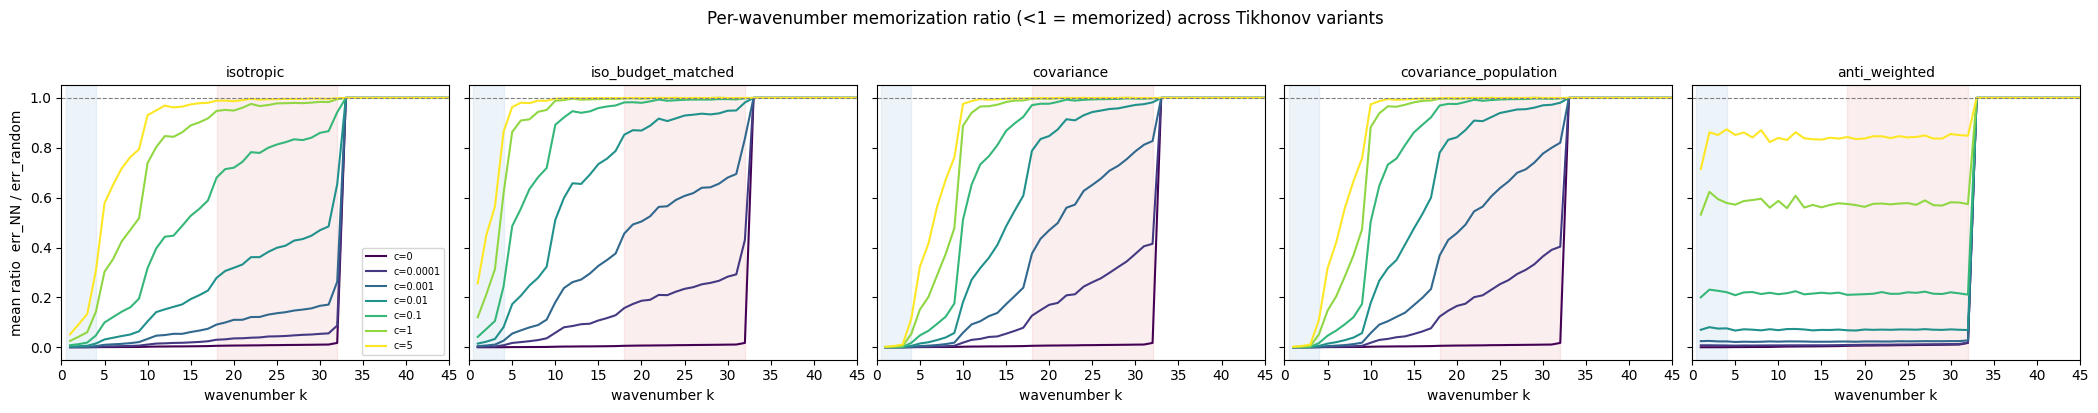

In [5]:
# -- Per-wavenumber ratio: one panel per variant --
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.2*len(VARIANTS), 4.0), sharey=True)
cmap = plt.cm.viridis
kc = ctx.k_centers.cpu().numpy()
for ax, variant in zip(axes, VARIANTS):
    for j, c_val in enumerate(C_VALUES):
        r = results[variant][c_val]['mean_ratio'].numpy()
        ax.plot(kc, r, color=cmap(j / (len(C_VALUES)-1)), lw=1.5, label=f'c={c_val:g}')
    for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=color, alpha=0.08)
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax.set_title(variant, fontsize=10)
    ax.set_xlabel('wavenumber k')
    ax.set_xlim(0, 45)
axes[0].set_ylabel('mean ratio  err_NN / err_random')
axes[0].legend(fontsize=7)
fig.suptitle('Per-wavenumber memorization ratio (<1 = memorized) across Tikhonov variants', y=1.02)
plt.tight_layout()
os.makedirs(os.path.join(repo_root, 'results', 'figures'), exist_ok=True)
plt.savefig(os.path.join(repo_root, 'results', 'figures', 'tikvariants_per_k.png'),
            dpi=150, bbox_inches='tight')
plt.show()

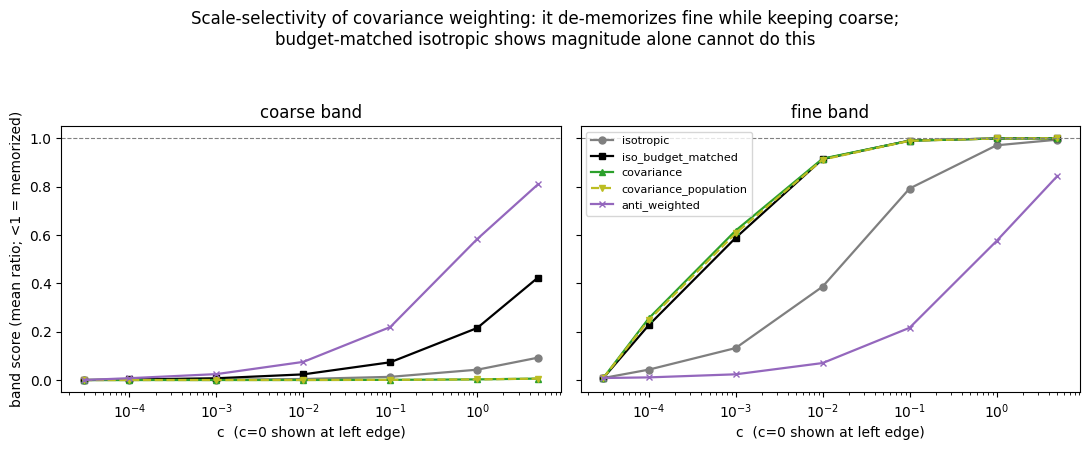

In [6]:
# -- Headline: coarse and fine band scores vs c, all variants --
styles = {
    'isotropic':             dict(color='tab:gray',   marker='o'),
    'iso_budget_matched':    dict(color='black',      marker='s'),
    'covariance':            dict(color='tab:green',  marker='^'),
    'covariance_population': dict(color='tab:olive',  marker='v', ls='--'),
    'anti_weighted':         dict(color='tab:purple', marker='x'),
}
c_plot = [c if c > 0 else 3e-5 for c in C_VALUES]   # place c=0 on the log axis

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, band in zip(axes, ['coarse', 'fine']):
    for variant in VARIANTS:
        ys = [results[variant][c][f'{band}_score'] for c in C_VALUES]
        ax.plot(c_plot, ys, lw=1.6, ms=5, label=variant, **styles[variant])
    ax.set_xscale('log')
    ax.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('c  (c=0 shown at left edge)')
    ax.set_title(f'{band} band')
axes[0].set_ylabel('band score (mean ratio; <1 = memorized)')
axes[1].legend(fontsize=8)
fig.suptitle('Scale-selectivity of covariance weighting: it de-memorizes fine while keeping coarse;\n'
             'budget-matched isotropic shows magnitude alone cannot do this', y=1.06)
plt.tight_layout()
plt.savefig(os.path.join(repo_root, 'results', 'figures', 'tikvariants_band_scores.png'),
            dpi=150, bbox_inches='tight')
plt.show()

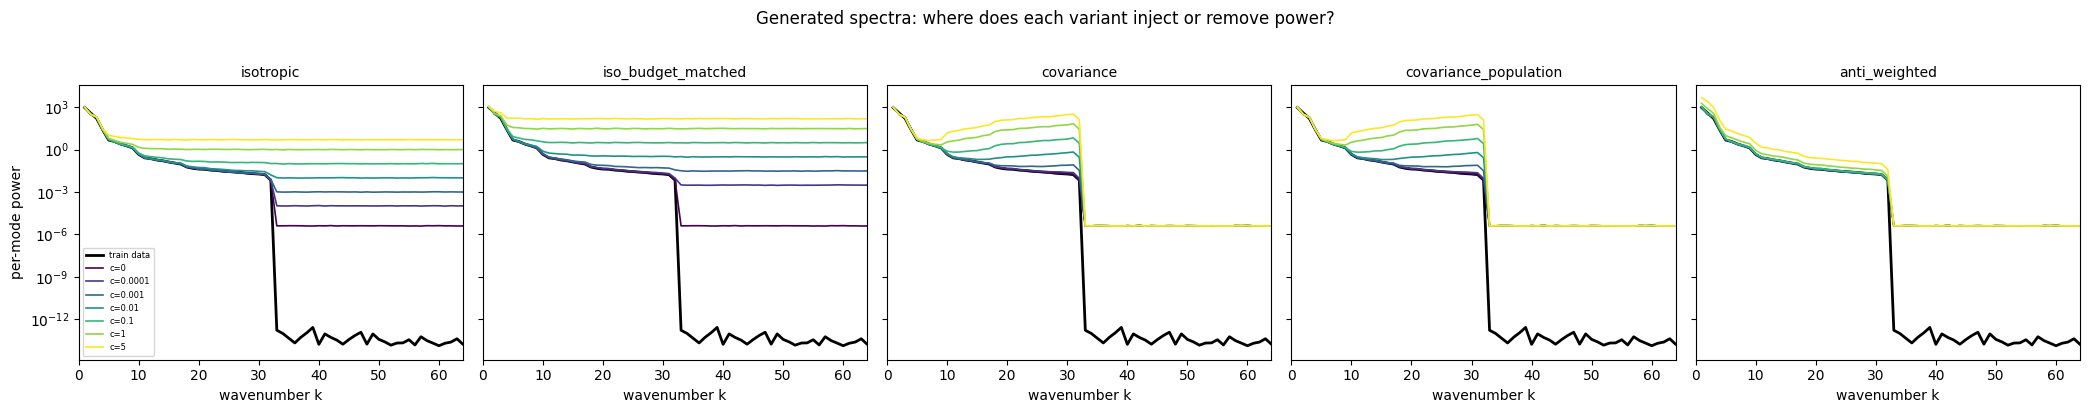

In [7]:
# -- Generated radial power spectra vs training data --
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.2*len(VARIANTS), 4.0), sharey=True)
for ax, variant in zip(axes, VARIANTS):
    ax.semilogy(kc, spectrum_train.cpu().numpy(), color='black', lw=2.0, label='train data')
    for j, c_val in enumerate(C_VALUES):
        g = results[variant][c_val]['gen_spectrum'].numpy()
        ax.semilogy(kc, np.clip(g, 1e-14, None), color=cmap(j / (len(C_VALUES)-1)),
                    lw=1.2, label=f'c={c_val:g}')
    ax.set_title(variant, fontsize=10)
    ax.set_xlabel('wavenumber k')
    ax.set_xlim(0, 64)
axes[0].set_ylabel('per-mode power')
axes[0].legend(fontsize=6)
fig.suptitle('Generated spectra: where does each variant inject or remove power?', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(repo_root, 'results', 'figures', 'tikvariants_generated_spectra.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# -- Summary table and save --
hdr = f'{"c":>8s}'
for v in VARIANTS:
    hdr += f' | {v[:14]:>14s}   '
print(hdr + '     (each: coarse / fine)')
print('-' * len(hdr))
for c_val in C_VALUES:
    row = f'{c_val:>8g}'
    for v in VARIANTS:
        e = results[v][c_val]
        row += f' | {e["coarse_score"]:.3f} / {e["fine_score"]:.3f} '
    print(row)

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)
save_obj = {
    'c_values': C_VALUES,
    'variants': VARIANTS,
    'results': results,
    'lam_emp': lam_emp.cpu(),
    'lam_pop': lam_pop.cpu(),
    'budget_factor': BUDGET_FACTOR,
    'null_rel_threshold': NULL_REL_THRESHOLD,
    'spectrum_train': spectrum_train.cpu(),
    'k_centers': ctx.k_centers.cpu(),
    'bands': bands,
    'n_train': N_TRAIN,
    'note': ('Tikhonov variants comparison (GMM closed form, VE_EDM, 500-step SDE, latents seed 42): '
             'isotropic (sigma^2+c), budget-matched isotropic (sigma^2 + c*mean_inband(1/lam)), '
             'covariance (sigma^2 + c/lam(k), empirical lam from n=32), covariance_population '
             '(lam from 2048 fresh fields, seed 7), anti_weighted (sigma^2 + c*lam(k)). '
             'Null modes unregularized in all weighted variants.'),
}
save_path = os.path.join(results_dir, 'gmm_tikhonov_variants_sweep.pt')
torch.save(save_obj, save_path)
print(f'\nResults saved to {save_path}')

       c |      isotropic    | iso_budget_mat    |     covariance    | covariance_pop    |  anti_weighted        (each: coarse / fine)
------------------------------------------------------------------------------------------------------------
       0 | 0.000 / 0.008  | 0.000 / 0.008  | 0.000 / 0.008  | 0.000 / 0.008  | 0.000 / 0.008 
  0.0001 | 0.000 / 0.043  | 0.002 / 0.227  | 0.000 / 0.255  | 0.000 / 0.248  | 0.008 / 0.011 
   0.001 | 0.001 / 0.132  | 0.007 / 0.588  | 0.000 / 0.618  | 0.000 / 0.607  | 0.025 / 0.024 
    0.01 | 0.004 / 0.386  | 0.023 / 0.914  | 0.000 / 0.916  | 0.000 / 0.912  | 0.075 / 0.070 
     0.1 | 0.013 / 0.792  | 0.074 / 0.990  | 0.001 / 0.990  | 0.001 / 0.989  | 0.219 / 0.216 
       1 | 0.043 / 0.971  | 0.215 / 0.999  | 0.003 / 0.999  | 0.003 / 0.999  | 0.583 / 0.575 
       5 | 0.093 / 0.994  | 0.424 / 1.000  | 0.006 / 1.000  | 0.006 / 1.000  | 0.810 / 0.844 

Results saved to /Users/ishittaiyer/Desktop/research-diffusion/results/data/gmm_tikhonov_variants

## Reading the results / notes for the reply to Prof. Baptista

- **`isotropic` vs `covariance`** is the direct answer to "the effect of this particular
  weighting": at matched scalar $c$, covariance weighting moves the fine band to ~1 about two
  orders of magnitude earlier in $c$, while the coarse band stays at its memorized level for
  every $c$ tested. Plain Tikhonov de-memorizes all bands together.
- **`iso_budget_matched`** rules out the trivial explanation that covariance weighting simply
  applies *more* regularization: with the same average effective constant applied uniformly,
  both bands de-memorize together — the selectivity comes from the *allocation* across modes,
  not the magnitude.
- **`anti_weighted`** shows direction-specificity: penalizing $\Sigma$ instead of
  $\Sigma^{-1}$ regularizes the high-variance coarse modes first, the mirror image.
- **`covariance_population`** checks that the empirical 32-sample spectrum is not doing
  anything special — the qualitative picture should be unchanged (per-mode estimation error
  ~14%).
- The generated-spectra panels show the isotropic variants inject a flat noise floor across
  all modes (including out-of-band $k>32$), while the weighted variants with pseudo-inverse
  null-mode handling keep out-of-band modes clean.

**Next:** the training-time U-Net analogue of the covariance penalty
(`edm_unet_covariance_tikhonov.ipynb`) — penalty $c\,\lambda(\sigma)\,\|D_\theta - x\|^2_{\Sigma}/\sigma^2$
as a Fourier-weighted MSE in `train_edm`.